<a href="https://colab.research.google.com/github/elajeans/IMAG2023/blob/main/oppgave3_4_py.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

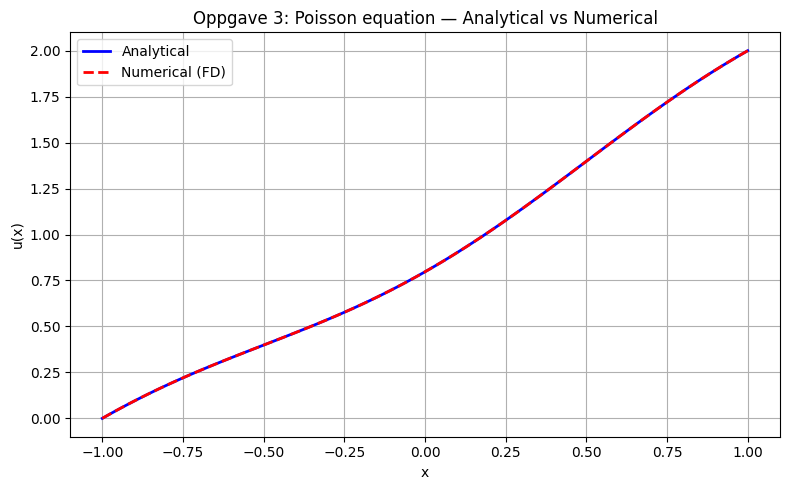

Oppgave 3 — Max error between analytical and numerical: 6.53e-05


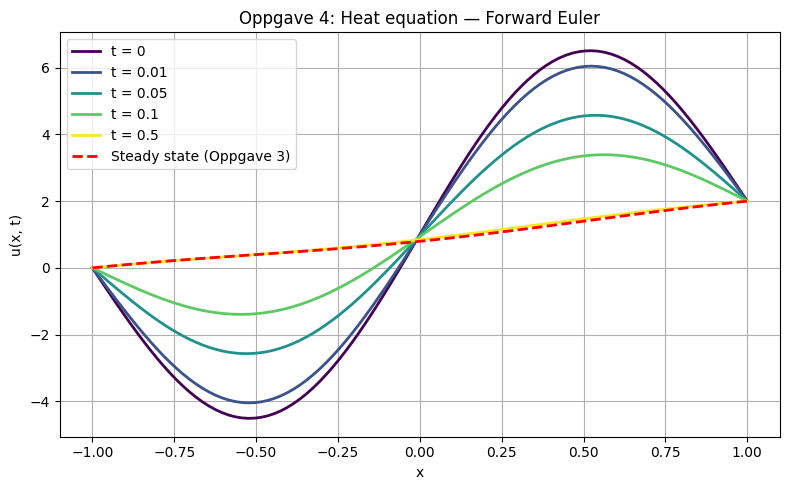

Oppgave 4 — Simulated 3187 steps with dt = 1.57e-04, h = 0.0198
Note: As t → ∞, the solution converges to the steady state from Oppgave 3.


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import solve

# ============================================================
# OPPGAVE 3: Poisson equation u_xx = cos(pi*x), -1 <= x <= 1
# BCs: u(-1) = 0, u(1) = 2
# ============================================================

# --- 3a) Analytical solution ---
def u_analytical(x):
    return -np.cos(np.pi * x) / np.pi**2 + x + 1 - 1/np.pi**2

# --- 3b) Numerical solution using finite differences ---
N = 100  # number of interior points
x_all = np.linspace(-1, 1, N + 2)
h = x_all[1] - x_all[0]
x_int = x_all[1:-1]  # interior points

# Build tridiagonal matrix A and RHS b
main_diag = -2 * np.ones(N)
off_diag  =  1 * np.ones(N - 1)
A = (np.diag(main_diag) + np.diag(off_diag, 1) + np.diag(off_diag, -1)) / h**2

f = np.cos(np.pi * x_int)
b = f.copy()

# Apply BCs to RHS
u_left, u_right = 0.0, 2.0
b[0]  -= u_left  / h**2
b[-1] -= u_right / h**2

# Solve linear system
u_num = solve(A, b)

# Full solution including boundary points
u_num_full = np.concatenate([[u_left], u_num, [u_right]])
u_ana_full = u_analytical(x_all)

# --- Plot Oppgave 3 ---
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(x_all, u_ana_full, 'b-',  lw=2, label='Analytical')
ax.plot(x_all, u_num_full, 'r--', lw=2, label='Numerical (FD)')
ax.set_xlabel('x')
ax.set_ylabel('u(x)')
ax.set_title('Oppgave 3: Poisson equation — Analytical vs Numerical')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.savefig('oppgave3.png', dpi=150)
plt.show()

max_err = np.max(np.abs(u_ana_full - u_num_full))
print(f"Oppgave 3 — Max error between analytical and numerical: {max_err:.2e}")


# ============================================================
# OPPGAVE 4: Heat equation u_t = u_xx - f(x)
# f(x) = cos(pi*x), IC: u(x,0) = 1 + x + 5*sin(pi*x)
# BCs: u(-1,t) = 0, u(1,t) = 2
# Method: Forward Euler
# ============================================================

# Grid
N4 = 100
x4 = np.linspace(-1, 1, N4 + 2)
h4 = x4[1] - x4[0]
x4_int = x4[1:-1]

# Time stepping: stability requires dt <= h^2 / 2
dt = 0.4 * h4**2   # safe choice (CFL < 0.5)
T_end = 0.5        # simulate until t = 0.5
n_steps = int(T_end / dt)

# Initial condition
u4 = 1 + x4 + 5 * np.sin(np.pi * x4)
u4[0]  = 0.0  # BC left
u4[-1] = 2.0  # BC right

f4 = np.cos(np.pi * x4_int)  # source term at interior points
r = dt / h4**2

# Store solution at a few time snapshots
snapshots = {}
snap_times = [0, 0.01, 0.05, 0.1, 0.5]
snap_steps = [int(t / dt) for t in snap_times]
snapshots[0] = u4.copy()

# Forward Euler time loop
u4_int = u4[1:-1].copy()
for n in range(1, n_steps + 1):
    u4_int_new = u4_int + r * (u4[:-2] - 2*u4_int + u4[2:]) - dt * f4
    u4_int = u4_int_new
    u4[1:-1] = u4_int
    u4[0] = 0.0
    u4[-1] = 2.0
    if n in snap_steps:
        snapshots[snap_times[snap_steps.index(n)]] = u4.copy()

# --- Plot Oppgave 4 ---
fig, ax = plt.subplots(figsize=(8, 5))
colors = plt.cm.viridis(np.linspace(0, 1, len(snapshots)))
for (t_val, u_snap), col in zip(sorted(snapshots.items()), colors):
    ax.plot(x4, u_snap, color=col, lw=2, label=f't = {t_val}')

# Overlay steady state (analytical solution from Oppgave 3)
ax.plot(x4, u_analytical(x4), 'r--', lw=2, label='Steady state (Oppgave 3)')
ax.set_xlabel('x')
ax.set_ylabel('u(x, t)')
ax.set_title('Oppgave 4: Heat equation — Forward Euler')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.savefig('oppgave4.png', dpi=150)
plt.show()

print(f"Oppgave 4 — Simulated {n_steps} steps with dt = {dt:.2e}, h = {h4:.4f}")
print("Note: As t → ∞, the solution converges to the steady state from Oppgave 3.")